In [2]:
#Define Constants
import numpy as np
import matplotlib.pyplot as plt

G = 6.67430e-11
M_sun = 1.989e30

M_tot = 2 * M_sun
e = 0.75
f0 = np.deg2rad(-135)
i = np.deg2rad(60)

# semimajor axes (in meters)
kau = 1000 * 1.496e11
a_values = [0.8 * kau, 8 * kau]

In [3]:
#Generate Orbital Phase Points
f_vals = np.linspace(0, 2*np.pi, 20)

In [4]:
#Compute Orbital Radius
def radius(a, e, f, f0):
    return a * (1 - e**2) / (1 + e * np.cos(f - f0))

In [5]:
#Position in Orbital Frame
def position_orbital(r, f):
    x = r * np.cos(f)
    y = r * np.sin(f)
    return x, y

In [6]:
#Transform to Observer Frame
def transform(x, y, i):
    xp = x
    yp = y * np.cos(i)
    zp = y * np.sin(i)
    return xp, yp, zp

In [7]:
#velocity Magnitude
def velocity_mag(r, a):
    return np.sqrt(G * M_tot * (2/r - 1/a))

In [8]:
#Direction of Velocity and Transform like positions-
def velocity_components(v, f):
    vx = -v * np.sin(f)
    vy = v * np.cos(f)
    return vx, vy

def transform_velocity(vx, vy, i):
    vxp = vx
    vyp = vy * np.cos(i)
    vzp = vy * np.sin(i)
    return vxp, vyp, vzp


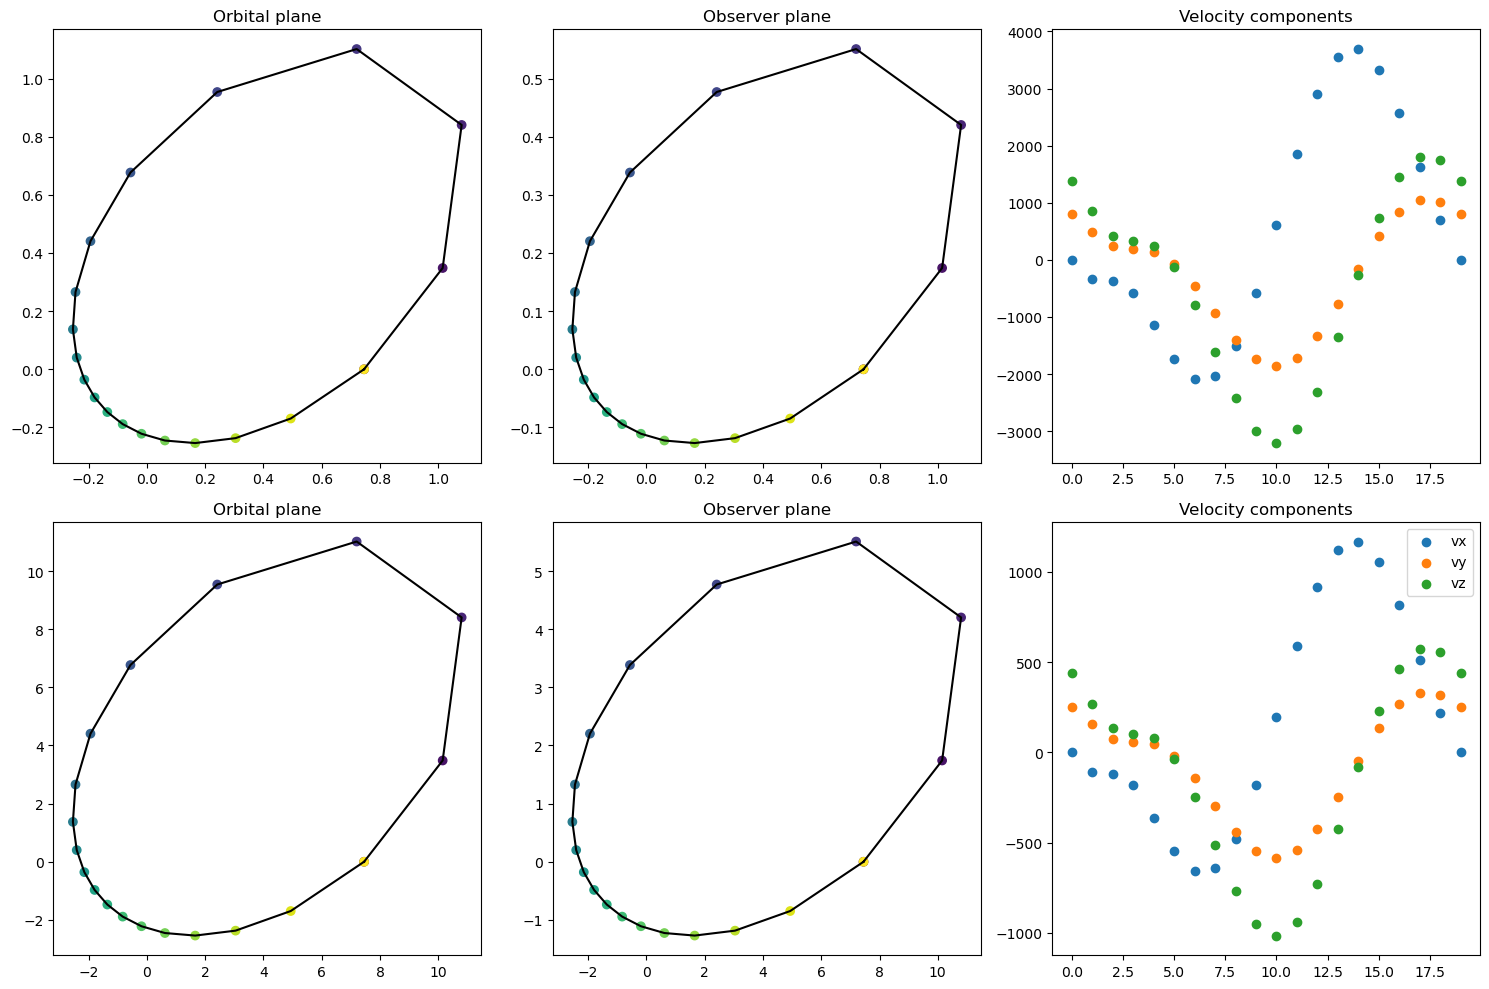

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for row, a in enumerate(a_values):
    xs, ys = [], []
    xps, yps = [], []
    vxs, vys, vzs = [], [], []

    for f in f_vals:
        r = radius(a, e, f, f0)

        x, y = position_orbital(r, f)
        xp, yp, zp = transform(x, y, i)

        v = velocity_mag(r, a)
        vx, vy = velocity_components(v, f)
        vxp, vyp, vzp = transform_velocity(vx, vy, i)

        xs.append(x/kau)
        ys.append(y/kau)

        xps.append(xp/kau)
        yps.append(yp/kau)

        vxs.append(vxp)
        vys.append(vyp)
        vzs.append(vzp)

    # Plot orbital plane
    axes[row, 0].plot(xs, ys, 'k-')
    axes[row, 0].scatter(xs, ys, c=range(len(xs)))
    axes[row, 0].set_title("Orbital plane")

    # Observer plane
    axes[row, 1].plot(xps, yps, 'k-')
    axes[row, 1].scatter(xps, yps, c=range(len(xs)))
    axes[row, 1].set_title("Observer plane")

    # Velocities
    axes[row, 2].scatter(range(len(vxs)), vxs, label='vx')
    axes[row, 2].scatter(range(len(vys)), vys, label='vy')
    axes[row, 2].scatter(range(len(vzs)), vzs, label='vz')
    axes[row, 2].set_title("Velocity components")

plt.legend()
plt.tight_layout()
plt.show()